In [211]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lobster import *

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [212]:
message_csv  = "/Users/rebeccalaik/Desktop/imperial/microstructure/LOBSTER_SampleFile_INTC_2012-06-21_5/INTC_2012-06-21_34200000_57600000_message_5.csv"
orderbook_csv = "/Users/rebeccalaik/Desktop/imperial/microstructure/LOBSTER_SampleFile_INTC_2012-06-21_5/INTC_2012-06-21_34200000_57600000_orderbook_5.csv"


msg, ob, qr, df = load_lobster_data(
    message_csv,
    orderbook_csv,
    levels=10,
    K=5
)

/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/i

In [213]:
aes = compute_aes_by_level(df, K=5)
df_norm = normalize_by_aes(df, aes, K=5) 

In [214]:
def shift_orderbook_before_event(df, K):

    df_shift = df.copy()

    for i in range(1, K+1):

        df_shift[f"Q_{i}"] = df_shift[f"Q_{i}"].shift(1)
        df_shift[f"Q_-{i}"] = df_shift[f"Q_-{i}"].shift(1)

    return df_shift


df_qr = shift_orderbook_before_event(df_norm, K=5)
df_qr = df_qr.dropna().reset_index(drop=True)

In [215]:
# Apply log(1+q) transform to queue sizes
def log_transform_queues(df, K):

    df = df.copy()

    for i in range(1, K+1):
        df[f"Q_{i}"] = np.log1p(df[f"Q_{i}"])
        df[f"Q_-{i}"] = np.log1p(df[f"Q_-{i}"])

    return df


df_qr = log_transform_queues(df_qr, K=5)

In [216]:
# Build additional MDQR state variables:
# - spread at the best prices
# - trade imbalance from bid and ask queue volumes
# - hour of the day
#- TI_rho(t_k) uses traded volumes on bid/ask sides over rolling time windows.

def add_mdqr_features(df, K, windows=(20.0, 60.0, 300.0, 900.0)):
   
    out = df.copy()

    # spread in ticks / price units
    out["spread"] = out["P_1"] - out["P_-1"]

    # traded volume by side:
    out["trade_bid_vol"] = np.where(out["type"] == "M", np.where(out["lvl"] > 0, out["size"], 0.0), 0.0)
    out["trade_ask_vol"] = np.where(out["type"] == "M", np.where(out["lvl"] < 0, out["size"], 0.0), 0.0)

    # rolling TI over time windows
    tmp = out[["time", "trade_bid_vol", "trade_ask_vol"]].copy()
    tmp["time_dt"] = pd.to_datetime(tmp["time"], unit="s")

    tmp = tmp.set_index("time_dt")

    for w in windows:
        bid_roll = tmp["trade_bid_vol"].rolling(f"{int(w)}s").sum()
        ask_roll = tmp["trade_ask_vol"].rolling(f"{int(w)}s").sum()

        ti = (bid_roll - ask_roll) / (bid_roll + ask_roll + 1e-8)

        if w == 20.0:
            col = "TI_20s"
        elif w == 60.0:
            col = "TI_1min"
        elif w == 300.0:
            col = "TI_5min"
        elif w == 900.0:
            col = "TI_15min"
        else:
            col = f"TI_{int(w)}s"

        out[col] = ti.values

    out[["TI_20s", "TI_1min", "TI_5min", "TI_15min"]] = (
        out[["TI_20s", "TI_1min", "TI_5min", "TI_15min"]].fillna(0.0)
    )

    out["hour"] = (out["time"] // 3600).astype(int)

    return out


df_qr = add_mdqr_features(df_qr, K=5)

In [217]:
#keep only the variable needed for the event by event MDQR sequence

def build_mdqr_sequence(df, K):

    q_cols = []

    for i in range(1, K+1):
        q_cols.append(f"Q_-{i}")

    for i in range(1, K+1):
        q_cols.append(f"Q_{i}")

    seq = df[
        ["type",
         "lvl",
         "size",
         "dtk",
         "spread",
         "TI_20s",
         "TI_1min",
         "TI_5min",
         "TI_15min",
         "hour"]
        + q_cols
    ].copy()

    seq = seq.reset_index(drop=True)

    return seq


mdqr_seq = build_mdqr_sequence(df_qr, K=5)

In [218]:
# si je comprends bien dans x_k il y a les previous-event features donc on ajoute:
# - previous event type
# - previous event level
# - previous event size

def add_previous_event_features(seq):

    df = seq.copy()

    df["omega_prev"] = df["type"].shift(1)
    df["level_prev"] = df["lvl"].shift(1)
    df["size_prev"] = df["size"].shift(1)

    return df


mdqr_seq = add_previous_event_features(mdqr_seq)

In [219]:
def add_mdqr_categorical_features(df, K):
    """
    Add only the categorical features from the paper:
    - omega: current event type code {L:0, C:1, M:2}  (needed for targets / size model)
    - hour_idx: categorical hour index
    - e_i: last event type at each level i before current event
    """
    out = df.copy()

    event_map = {"L": 0, "C": 1, "M": 2}
    pad_code = 3

    # current event type (kept for targets and size model conditioning)
    out["omega"] = out["type"].map(event_map).astype(int)

    # remove first row 
    out = out[out["type"].notna()].copy()

    # categorical hour index
    unique_hours = sorted(out["hour"].dropna().unique().tolist())
    hour_to_idx = {h: i for i, h in enumerate(unique_hours)}
    out["hour_idx"] = out["hour"].map(hour_to_idx).astype(int)

    # level last event type e_i(t_k)
    levels = list(range(-K, 0)) + list(range(1, K + 1))

    for lvl in levels:
        col = f"e_{lvl}"

        cur_lvl_event = np.where(out["lvl"] == lvl, out["omega"], np.nan)
        last_lvl_event = pd.Series(cur_lvl_event, index=out.index).ffill().shift(1)

        out[col] = last_lvl_event.fillna(pad_code).astype(int)

    out = out.reset_index(drop=True)
    return out, hour_to_idx

In [220]:
mdqr_seq, hour_to_idx = add_mdqr_categorical_features(mdqr_seq, K=5)

In [221]:
# Split the state vector into:
# - numerical features
# - level-wise categorical features e_i(t_k)
# - categorical hour feature

def build_mdqr_state_components(df, K):
    q_cols = [f"Q_-{i}" for i in range(1, K+1)] + [f"Q_{i}" for i in range(1, K+1)]
    e_cols = [f"e_{i}" for i in list(range(-K, 0)) + list(range(1, K+1))]

    # numerical features 
    X_num = df[
    q_cols + ["spread", "TI_20s", "TI_1min", "TI_5min", "TI_15min"]
].copy()

    # categorical features with embeddings
    X_cat_levels = df[e_cols].copy()
    X_cat_hour = df["hour_idx"].copy()

    return X_num, X_cat_levels, X_cat_hour


X_num, X_cat_levels, X_cat_hour = build_mdqr_state_components(mdqr_seq, K=5)

In [222]:
# Encode each (event type, price level) pair as one class in {0,...,3*2K-1}.
# For K=5, this gives 30 event-level classes.

def encode_event_level(event, level, K=5):

    level = int(level)

    side_offset = 0 if level < 0 else K

    level_index = abs(level) - 1

    return event * (2*K) + side_offset + level_index

In [223]:
# Build the target y_event_level corresponding to the observed class
# (event type, level) for each row in the MDQR sequence.

def build_mdqr_targets(df, K=5):

    y_event_level = []

    for e,l in zip(df["omega"], df["lvl"]):
        y_event_level.append(encode_event_level(e,l,K))

    y_event_level = np.array(y_event_level)

    return y_event_level


y_event_level = build_mdqr_targets(mdqr_seq)

In [224]:
# Discretize order sizes into quantile-based bins.
# This transforms the size model into a classification problem.

def build_size_bins(size_series, n_bins=200):

    bins = pd.qcut(size_series, q=n_bins, duplicates="drop")

    labels = bins.cat.codes

    return labels, bins


size_classes, size_bins = build_size_bins(mdqr_seq["size"])

mdqr_seq["size_class"] = size_classes

In [225]:
class IntensityNet(nn.Module):

    def __init__(
        self,
        num_numeric_features,
        num_level_cats,
        num_hour_classes,
        emb_dim_level=2,
        emb_dim_hour=2,
        output_dim=30
    ):
        super().__init__()

        self.level_event_emb = nn.Embedding(4, emb_dim_level)   
        self.hour_emb = nn.Embedding(num_hour_classes, emb_dim_hour)

        input_dim = num_numeric_features + num_level_cats * emb_dim_level + emb_dim_hour

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 64),
            nn.Tanh(),
            nn.Linear(64, output_dim),
            nn.ReLU()
        )

    def forward(self, x_num, x_cat_levels, x_cat_hour):
        lvl_emb = self.level_event_emb(x_cat_levels).reshape(x_cat_levels.size(0), -1)
        hour_emb = self.hour_emb(x_cat_hour)
        x = torch.cat([x_num, lvl_emb, hour_emb], dim=1)
        return self.net(x)

In [226]:
class SizeNet(nn.Module):

    def __init__(
        self,
        num_numeric_features,
        num_level_cats,
        num_hour_classes,
        emb_dim_level=2,
        emb_dim_hour=2,
        num_classes=200
    ):
        super().__init__()

        self.level_event_emb = nn.Embedding(4, emb_dim_level)
        self.hour_emb = nn.Embedding(num_hour_classes, emb_dim_hour)

        input_dim = num_numeric_features + num_level_cats * emb_dim_level + emb_dim_hour + 2

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 64),
            nn.Tanh(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x_num, x_cat_levels, x_cat_hour, omega_cur, lvl_cur):
        lvl_emb = self.level_event_emb(x_cat_levels).reshape(x_cat_levels.size(0), -1)
        hour_emb = self.hour_emb(x_cat_hour)
        extra = torch.stack([omega_cur.float(), lvl_cur.float()], dim=1)
        x = torch.cat([x_num, lvl_emb, hour_emb, extra], dim=1)
        return self.net(x)

In [227]:
def intensity_loss(lam,y,dt):

    lam_sum = lam.sum(dim=1)

    lam_event = lam[torch.arange(len(y)),y]

    loss = -(torch.log(lam_event+1e-8)-lam_sum*dt)

    return loss.mean()


size_loss = nn.CrossEntropyLoss()

In [228]:
# Build the dataset and dataloader used for stochastic mini-batch training.

class MDQRDataset(Dataset):

    def __init__(self, X_num, X_cat_levels, X_cat_hour, df, K=5):

        X_num_clean = X_num.apply(pd.to_numeric, errors="coerce").fillna(0.0)
        X_cat_levels_clean = X_cat_levels.apply(pd.to_numeric, errors="coerce").fillna(3)

        self.x_num = torch.tensor(
            X_num_clean.values.astype(np.float32),
            dtype=torch.float32
        )

        self.x_cat_levels = torch.tensor(
            X_cat_levels_clean.values.astype(np.int64),
            dtype=torch.long
        )

        self.x_cat_hour = torch.tensor(
            X_cat_hour.values.astype(np.int64),
            dtype=torch.long
        )

        self.dt = torch.tensor(
            df["dtk"].astype(float).values,
            dtype=torch.float32
        )

        self.y_event_level = torch.tensor(
            build_mdqr_targets(df, K=K),
            dtype=torch.long
        )

        self.y_size = torch.tensor(
            df["size_class"].astype(int).values,
            dtype=torch.long
        )

        self.omega_cur = torch.tensor(
            df["omega"].astype(int).values,
            dtype=torch.long
        )

        self.lvl_cur = torch.tensor(
            df["lvl"].astype(int).values,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.x_num)

    def __getitem__(self, idx):
        return (
            self.x_num[idx],
            self.x_cat_levels[idx],
            self.x_cat_hour[idx],
            self.y_event_level[idx],
            self.y_size[idx],
            self.dt[idx],
            self.omega_cur[idx],
            self.lvl_cur[idx]
        )

In [229]:
dataset = MDQRDataset(X_num, X_cat_levels, X_cat_hour, mdqr_seq, K=5)

loader = DataLoader(
    dataset,
    batch_size=1024,
    shuffle=True
)

In [230]:
num_numeric_features = X_num.shape[1]
num_level_cats = X_cat_levels.shape[1]
num_hour_classes = mdqr_seq["hour_idx"].nunique()

model_intensity = IntensityNet(
    num_numeric_features=num_numeric_features,
    num_level_cats=num_level_cats,
    num_hour_classes=num_hour_classes,
    emb_dim_level=2,
    emb_dim_hour=2,
    output_dim=30
)

model_size = SizeNet(
    num_numeric_features=num_numeric_features,
    num_level_cats=num_level_cats,
    num_hour_classes=num_hour_classes,
    emb_dim_level=2,
    emb_dim_hour=2,
    num_classes=200
)

In [231]:
#training of the two MDQR components
# The total loss is:
# - Poisson negative log-likelihood for event/time
# - cross-entropy for order size classification
loss_history = []

opt = optim.Adam(
    list(model_intensity.parameters()) +
    list(model_size.parameters()),
    lr=1e-4
)

for epoch in range(80):

    total_loss = 0.0

    for x_num_b, x_cat_levels_b, x_cat_hour_b, y_ev, y_sz, dt_b, omega_cur_b, lvl_cur_b in loader:

        lam = model_intensity(x_num_b, x_cat_levels_b, x_cat_hour_b)
        loss_int = intensity_loss(lam, y_ev, dt_b)

        size_logits = model_size(
            x_num_b,
            x_cat_levels_b,
            x_cat_hour_b,
            omega_cur_b,
            lvl_cur_b
        )
        loss_size_val = size_loss(size_logits, y_sz)

        loss = loss_int + loss_size_val

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    loss_history.append(total_loss)
    print(epoch, total_loss)

0 1318.941647052765
1 711.5064275860786
2 644.0290536880493
3 621.5332651734352
4 611.9514588713646
5 604.3689230680466
6 588.0541048049927
7 553.504690438509
8 521.3413542509079
9 488.22150433063507
10 452.26716044545174
11 418.8358272612095
12 386.633024841547
13 364.1319832801819
14 336.9425111711025
15 319.31860338151455
16 307.21091386675835
17 306.7192064076662
18 278.3024155944586
19 270.02416791021824
20 260.11431908607483
21 250.877617970109
22 249.7744382917881
23 234.93777926266193
24 228.9819879680872
25 475.0538212954998
26 329.77775590121746
27 300.564204454422
28 291.51256911456585
29 282.5218581855297
30 274.02922843396664
31 266.2429189234972
32 256.0612864047289
33 247.40782171487808
34 236.3681080788374
35 226.14624653756618
36 213.853271946311
37 206.59905125200748
38 196.0016090720892
39 192.4857692271471
40 188.02936175465584
41 184.5612574517727
42 210.4305917918682
43 202.04584209620953
44 181.39182090759277
45 174.19464549422264
46 192.03278774023056
47 172.076

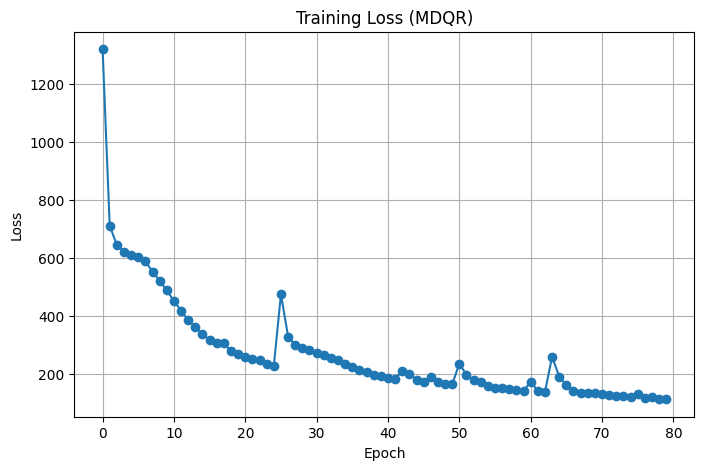

In [232]:
# Plot training loss 
plt.figure(figsize=(8,5))

plt.plot(loss_history, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (MDQR)")
plt.grid(True)

plt.show()

In [233]:
# Rebuild the full state tensors

X_num_clean = X_num.apply(pd.to_numeric, errors="coerce").fillna(0.0)
X_cat_levels_clean = X_cat_levels.apply(pd.to_numeric, errors="coerce").fillna(3)

x_num_tensor = torch.tensor(
    X_num_clean.values.astype(np.float32),
    dtype=torch.float32
)

x_cat_levels_tensor = torch.tensor(
    X_cat_levels_clean.values.astype(np.int64),
    dtype=torch.long
)

x_cat_hour_tensor = torch.tensor(
    X_cat_hour.values.astype(np.int64),
    dtype=torch.long
)

model_intensity.eval()
with torch.no_grad():
    lam = model_intensity(
        x_num_tensor,
        x_cat_levels_tensor,
        x_cat_hour_tensor
    ).cpu().numpy()

In [234]:
#construction transition matrix 

EVENTS = [
    "cancel_ask",
    "cancel_bid",
    "limit_ask",
    "limit_bid",
    "trade_ask",
    "trade_bid"
]

def label_event(row):
    """
    Map historical event (type, lvl) -> one of the 6 labels:
    cancel_ask, cancel_bid, limit_ask, limit_bid, trade_ask, trade_bid

    Convention in your preprocessing:
    - L/C: lvl > 0 => ask, lvl < 0 => bid
    - M:   lvl < 0 => trade_ask, lvl > 0 => trade_bid
    """
    t = row["type"]
    lvl = row["lvl"]

    if t == "L":
        base = "limit"
        side = "ask" if lvl > 0 else "bid"

    elif t == "C":
        base = "cancel"
        side = "ask" if lvl > 0 else "bid"

    elif t == "M":
        base = "trade"
        side = "ask" if lvl < 0 else "bid"

    else:
        raise ValueError(f"Unknown event type: {t}")

    return f"{base}_{side}"

In [235]:
def row_normalize(counts):
    """
    Robust row normalization:
    if a row sum is zero, return zeros instead of NaN.
    """
    row_sums = counts.sum(axis=1)
    return counts.div(row_sums.replace(0, np.nan), axis=0).fillna(0.0)

In [236]:
# 1) Real transition matrix

d = mdqr_seq.copy()

# Figure 9 focuses on best prices
d = d[d["lvl"].abs() == 1].copy()

d["event"] = d.apply(label_event, axis=1)
d["prev_event"] = d["event"].shift(1)

counts_real = pd.crosstab(d["prev_event"], d["event"])
counts_real = counts_real.reindex(index=EVENTS, columns=EVENTS, fill_value=0)

real_mat = row_normalize(counts_real)

print("REAL TRANSITION MATRIX")
print(real_mat.round(3))


REAL TRANSITION MATRIX
event       cancel_ask  cancel_bid  limit_ask  limit_bid  trade_ask  trade_bid
prev_event                                                                    
cancel_ask       0.362       0.095      0.337      0.178      0.017      0.011
cancel_bid       0.081       0.322      0.150      0.420      0.013      0.012
limit_ask        0.277       0.142      0.476      0.082      0.016      0.007
limit_bid        0.130       0.353      0.070      0.429      0.007      0.011
trade_ask        0.040       0.067      0.110      0.031      0.749      0.002
trade_bid        0.063       0.045      0.035      0.123      0.002      0.732


In [237]:
# 2) Simulated transition matrix from trained MDQR
# Decode event-level predictions, sample a simulated event sequence from the learned
# intensities, restrict to best-price events, and compute the simulated transition matrix

def decode_event_level(c, K=5):
    event = c // (2 * K)
    pos = c % (2 * K)

    if pos < K:
        lvl = -(pos + 1)
    else:
        lvl = pos - K + 1

    return event, lvl


def sample_from_prob(prob):
    rng = np.random.default_rng()
    return rng.choice(len(prob), p=prob)


def size_class_to_value(size_class, size_bins):
    """
    Convert predicted size class into a representative size value
    using the midpoint of the corresponding quantile interval.
    """
    interval = size_bins.cat.categories[size_class]
    return float((interval.left + interval.right) / 2.0)


def event_label_from_type_level(t, l):
    if t == "L":
        base = "limit"
        side = "ask" if l > 0 else "bid"
    elif t == "C":
        base = "cancel"
        side = "ask" if l > 0 else "bid"
    elif t == "M":
        base = "trade"
        side = "ask" if l < 0 else "bid"
    else:
        raise ValueError(f"Unknown event type: {t}")

    return f"{base}_{side}"

In [238]:
def apply_event_to_state(x_num_row, x_cat_levels_row, event_type_code, lvl, size_value, K=5):
    """
    Minimal recursive update of the simulated state.
    """
    x_num_new = x_num_row.copy()
    x_cat_new = x_cat_levels_row.copy()

    # queue column name
    q_col = f"Q_{lvl}"

    # because queues are stored as log(1+q), update in raw domain then transform back
    q_old_log = float(x_num_new[q_col])
    q_old = np.expm1(q_old_log)

    if event_type_code == 0:      # Limit order
        q_new = q_old + size_value
    elif event_type_code in [1, 2]:  # Cancel or Market
        q_new = max(0.0, q_old - size_value)
    else:
        q_new = q_old

    x_num_new[q_col] = np.log1p(q_new)

    # update last-event categorical feature at that level
    x_cat_new[f"e_{lvl}"] = int(event_type_code)

    return x_num_new, x_cat_new

In [239]:
def simulate_mdqr_market(
    model_intensity,
    model_size,
    X_num,
    X_cat_levels,
    X_cat_hour,
    size_bins,
    n_steps=50000,
    K=5
):
    """
    Simulate a recursive market trajectory using both:
    - IntensityNet for event type/level
    - SizeNet for order size class

    Returns a DataFrame of simulated events.
    """
    model_intensity.eval()
    model_size.eval()

    # start from the first observed state
    x_num_state = X_num.iloc[0].copy()
    x_cat_levels_state = X_cat_levels.iloc[0].copy()
    x_cat_hour_state = int(X_cat_hour.iloc[0])

    event_map = {0: "L", 1: "C", 2: "M"}

    sim_records = []

    for _ in range(n_steps):

        # prepare tensors
        x_num_tensor = torch.tensor(
            x_num_state.values.astype(np.float32)[None, :],
            dtype=torch.float32
        )

        x_cat_levels_tensor = torch.tensor(
            x_cat_levels_state.values.astype(np.int64)[None, :],
            dtype=torch.long
        )

        x_cat_hour_tensor = torch.tensor(
            np.array([x_cat_hour_state], dtype=np.int64),
            dtype=torch.long
        )

        # 1) intensity model -> sample event class
        with torch.no_grad():
            lam = model_intensity(
                x_num_tensor,
                x_cat_levels_tensor,
                x_cat_hour_tensor
            ).cpu().numpy()[0]

        lam = np.maximum(lam, 1e-12)
        prob_event = lam / lam.sum()

        event_class = sample_from_prob(prob_event)
        event_type_code, lvl = decode_event_level(event_class, K=K)

        # 2) size model -> sample size class
        omega_cur_tensor = torch.tensor([event_type_code], dtype=torch.long)
        lvl_cur_tensor = torch.tensor([lvl], dtype=torch.long)

        with torch.no_grad():
            size_logits = model_size(
                x_num_tensor,
                x_cat_levels_tensor,
                x_cat_hour_tensor,
                omega_cur_tensor,
                lvl_cur_tensor
            )

        size_prob = torch.softmax(size_logits, dim=1).cpu().numpy()[0]
        size_class = sample_from_prob(size_prob)
        size_value = size_class_to_value(size_class, size_bins)

        # 3) record event
        event_type = event_map[event_type_code]
        event_label = event_label_from_type_level(event_type, lvl)

        sim_records.append({
            "type": event_type,
            "lvl": lvl,
            "size": size_value,
            "event": event_label
        })

        # 4) update state using sampled event and sampled size
        x_num_state, x_cat_levels_state = apply_event_to_state(
            x_num_state,
            x_cat_levels_state,
            event_type_code,
            lvl,
            size_value,
            K=K
        )

        # hour kept fixed here; could be updated with simulated time if you later simulate dtk too

    return pd.DataFrame(sim_records)

In [240]:
# Run recursive MDQR market simulation 

sim = simulate_mdqr_market(
    model_intensity=model_intensity,
    model_size=model_size,
    X_num=X_num,
    X_cat_levels=X_cat_levels,
    X_cat_hour=X_cat_hour,
    size_bins=size_bins,
    n_steps=50000,
    K=5
)

print("SIMULATED EVENT TYPES")
print(sim["type"].value_counts())

print("\nSIMULATED BEST-PRICE EVENT TYPES")
print(sim[sim["lvl"].abs() == 1]["type"].value_counts())

sim_best = sim[sim["lvl"].abs() == 1].copy()
sim_best["prev_event"] = sim_best["event"].shift(1)

counts_sim = pd.crosstab(sim_best["prev_event"], sim_best["event"])
counts_sim = counts_sim.reindex(index=EVENTS, columns=EVENTS, fill_value=0)

sim_mat = row_normalize(counts_sim)

print("\nSIMULATED TRANSITION MATRIX (MDQR)")
print(sim_mat.round(3))

SIMULATED EVENT TYPES
type
L    25943
C    20516
M     3541
Name: count, dtype: int64

SIMULATED BEST-PRICE EVENT TYPES
type
L    15620
C    13288
M     3540
Name: count, dtype: int64

SIMULATED TRANSITION MATRIX (MDQR)
event       cancel_ask  cancel_bid  limit_ask  limit_bid  trade_ask  trade_bid
prev_event                                                                    
cancel_ask       0.365       0.046      0.433      0.045      0.104      0.007
cancel_bid       0.296       0.144      0.392      0.073      0.071      0.026
limit_ask        0.343       0.061      0.464      0.024      0.103      0.006
limit_bid        0.303       0.118      0.286      0.195      0.065      0.033
trade_ask        0.357       0.043      0.472      0.015      0.114      0.000
trade_bid        0.197       0.251      0.224      0.171      0.047      0.110


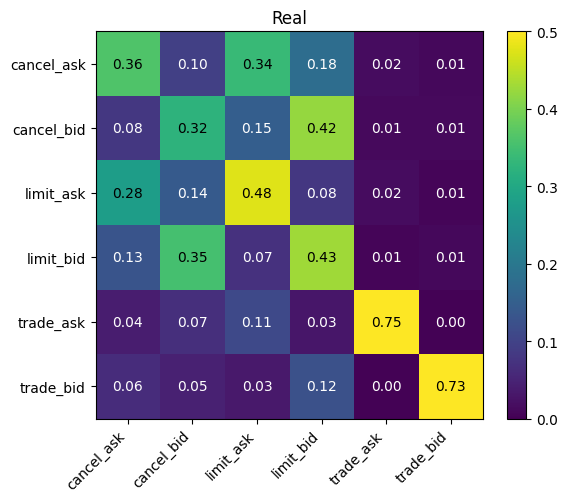

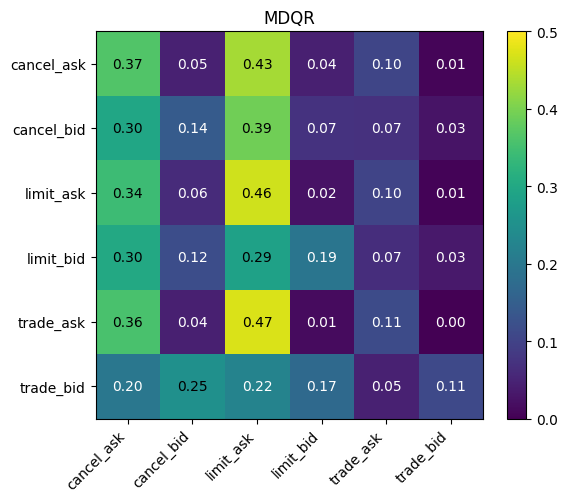

/var/folders/1f/ls1_y4xn1ljfvp6h5bvx9b580000gn/T/ipykernel_7861/3327935528.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


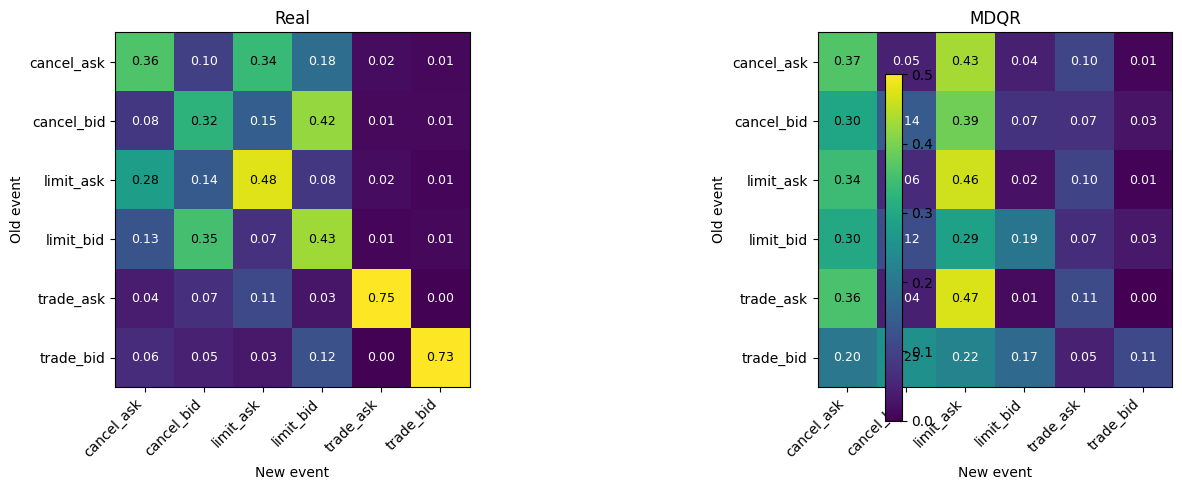

In [243]:
# 3) Plotting

def plot_transition(mat, title, vmin=0.0, vmax=0.5):
    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(mat.values, vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(mat.columns)))
    ax.set_yticks(range(len(mat.index)))

    ax.set_xticklabels(mat.columns, rotation=45, ha="right")
    ax.set_yticklabels(mat.index)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            color = "white" if val < 0.25 else "black"
            ax.text(j, i, f"{val:.2f}",
                    ha="center", va="center", color=color, fontsize=10)

    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def plot_transition_side_by_side(real_mat, sim_mat, vmin=0.0, vmax=0.5):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, mat, title in zip(
        axes,
        [real_mat, sim_mat],
        ["Real", "MDQR"]
    ):
        im = ax.imshow(mat.values, vmin=vmin, vmax=vmax)

        ax.set_xticks(range(len(mat.columns)))
        ax.set_yticks(range(len(mat.index)))

        ax.set_xticklabels(mat.columns, rotation=45, ha="right")
        ax.set_yticklabels(mat.index)

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat.iloc[i, j]
                color = "white" if val < 0.25 else "black"
                ax.text(j, i, f"{val:.2f}",
                        ha="center", va="center", color=color, fontsize=9)

        ax.set_title(title)
        ax.set_xlabel("New event")
        ax.set_ylabel("Old event")

    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9)
    plt.tight_layout()
    plt.show()


# individual plots
plot_transition(real_mat, "Real")
plot_transition(sim_mat, "MDQR")

# side-by-side plot 
plot_transition_side_by_side(real_mat, sim_mat)